In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [3]:
import numpy as np
import pandas as pd

# CSV 파일의 컬럼 이름 지정 (첫 번째 컬럼은 버릴 값이므로 "NaN"으로 명명)
names = ["NaN", "user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis"]

# CSV 파일 읽기 (header 없이, 첫 줄은 skip)
data = pd.read_csv("/Users/ohheungchan/workspace/AI_Study/paperwork/WISDM.csv",
                   header=None, names=names, skiprows=1)

# "NaN" 컬럼 제거
df = data.drop('NaN', axis=1)

# 'z_axis' 컬럼을 문자열로 변환 후 세미콜론(;) 제거
df["z_axis"] = df["z_axis"].astype(str).str.replace(';', '', regex=True)

# 문자열 데이터를 float으로 변환 (에러 발생 시 NaN으로 처리)
df["timestamp"] = pd.to_numeric(df["timestamp"], errors='coerce')
df["x_axis"]    = pd.to_numeric(df["x_axis"], errors='coerce')
df["y_axis"]    = pd.to_numeric(df["y_axis"], errors='coerce')
df["z_axis"]    = pd.to_numeric(df["z_axis"], errors='coerce')

# 결측치가 있는 행 제거
df.dropna(axis=0, how='any', inplace=True)

# 결과 확인
print(df.head())
print("DataFrame shape:", df.shape)

   user_id activity       timestamp    x_axis     y_axis    z_axis
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164
DataFrame shape: (1098203, 6)


In [4]:
# 타임스탬프를 기준으로 정렬한 후, 각 activity 그룹에서 마지막 24,000개 샘플을 test 셋으로 선택
test_df = data.groupby("activity", group_keys=False).apply(
    lambda x: x.sort_values("timestamp").tail(24000)
)

# test_df에 포함된 인덱스를 제외한 나머지를 train 셋으로 지정
train_df = data.drop(test_df.index)

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# 각 그룹별 분포 확인 (타임스탬프 기반으로 분할한 경우에도 각 그룹의 샘플 수는 동일해야 함)
print("Train set activity distribution:")
print(train_df["activity"].value_counts())
print("\nTest set activity distribution:")
print(test_df["activity"].value_counts())

Train set shape: (954203, 7)
Test set shape: (144000, 7)
Train set activity distribution:
activity
Walking       400397
Jogging       318176
Upstairs       98869
Downstairs     76427
Sitting        35939
Standing       24395
Name: count, dtype: int64

Test set activity distribution:
activity
Downstairs    24000
Jogging       24000
Sitting       24000
Standing      24000
Upstairs      24000
Walking       24000
Name: count, dtype: int64


/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_49051/3501039775.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = data.groupby("activity", group_keys=False).apply(


In [5]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# from sklearn.preprocessing import OneHotEncoder  # CrossEntropyLoss는 정수형 라벨을 사용하므로 OneHot은 필요없음

#############################################
# 1. 데이터 전처리 및 레이블 인코딩
#############################################
# df는 이미 'x_axis', 'y_axis', 'z_axis', 'activity' 컬럼을 가진 DataFrame이라고 가정합니다.
le = LabelEncoder()
train_df['ActivityEncoded'] = le.fit_transform(train_df['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)
le = LabelEncoder()
test_df['ActivityEncoded'] = le.fit_transform(test_df['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)

활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']
활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']


In [6]:
train_df.activity.value_counts()

activity
Walking       400397
Jogging       318176
Upstairs       98869
Downstairs     76427
Sitting        35939
Standing       24395
Name: count, dtype: int64

<Axes: xlabel='activity', ylabel='count'>

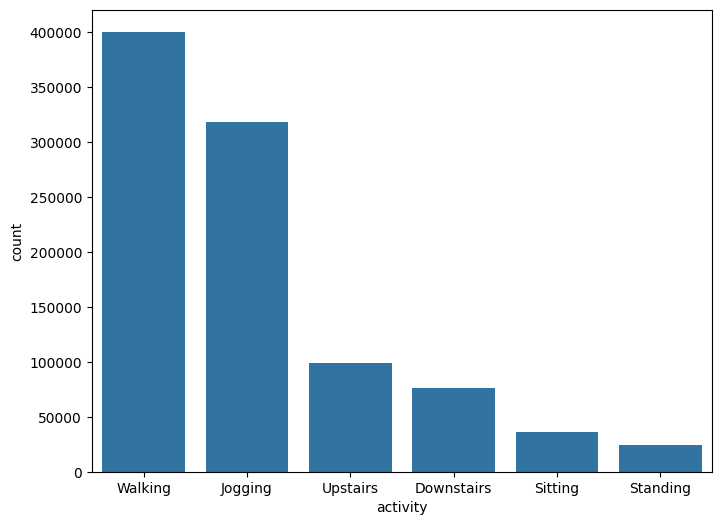

In [12]:
plt.figure(figsize=(8, 6))
sns.countplot(x = "activity", data = train_df, order = train_df.activity.value_counts().index)
     

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# 1. GAN 모델 정의
# ---------------------------
class Generator(nn.Module):
    def __init__(self, noise_dim=16, output_dim=3, hidden_dim=64):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim * 2, output_dim),
            nn.Tanh()  # 출력 범위를 [-1, 1]로 조정 (데이터 정규화 여부에 따라 변경)
        )
    
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)


In [14]:
# ---------------------------
# 2. GAN 학습 함수
# ---------------------------
def train_gan(minority_data, noise_dim=16, batch_size=32, epochs=500, device='cpu'):
    """
    minority_data: numpy array, shape (N, 3) – 해당 클래스의 센서 데이터
    """
    dataset = TensorDataset(torch.tensor(minority_data, dtype=torch.float32))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    generator = Generator(noise_dim=noise_dim, output_dim=3, hidden_dim=64).to(device)
    discriminator = Discriminator(input_dim=3, hidden_dim=64).to(device)

    opt_gen = optim.Adam(generator.parameters(), lr=0.001)
    opt_disc = optim.Adam(discriminator.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        for batch in dataloader:
            real_data = batch[0].to(device)
            current_batch = real_data.size(0)

            # Discriminator 학습
            noise = torch.randn(current_batch, noise_dim).to(device)
            fake_data = generator(noise)
            
            disc_real = discriminator(real_data)
            disc_fake = discriminator(fake_data.detach())
            
            loss_real = criterion(disc_real, torch.ones_like(disc_real))
            loss_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
            loss_disc = (loss_real + loss_fake) / 2

            opt_disc.zero_grad()
            loss_disc.backward()
            opt_disc.step()

            # Generator 학습
            noise = torch.randn(current_batch, noise_dim).to(device)
            fake_data = generator(noise)
            disc_fake = discriminator(fake_data)
            loss_gen = criterion(disc_fake, torch.ones_like(disc_fake))

            opt_gen.zero_grad()
            loss_gen.backward()
            opt_gen.step()
            
        if epoch % 50 == 0:
            print(f"Epoch {epoch}/{epochs} - Loss_D: {loss_disc.item():.4f}, Loss_G: {loss_gen.item():.4f}")
    
    return generator

In [15]:

# ---------------------------
# 3. 합성 데이터 생성 함수
# ---------------------------
def generate_synthetic_samples(generator, num_samples, noise_dim=16, device='cpu'):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num_samples, noise_dim).to(device)
        synthetic_data = generator(noise)
    return synthetic_data.cpu().numpy()

In [16]:
# ---------------------------
# 4. GAN을 이용한 데이터 밸런싱 함수 (랜덤 샘플링 80%, GAN 증강 20%)
# ---------------------------
def balance_dataset_with_gan(train_df, noise_dim=16, batch_size=32, epochs=500):
    """
    train_df: 원본 트레인 데이터프레임 (컬럼: 'x_axis', 'y_axis', 'z_axis', 'activity')
    각 클래스별 샘플 수를 Walking의 수로 맞추되,
    부족한 샘플 중 80%는 원본에서 랜덤 오버샘플링, 20%는 GAN 증강으로 채웁니다.
    """
    # 디바이스 설정: Apple Silicon(MPS) > CUDA > CPU
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print("Using device:", device)
    
    # 각 클래스의 원본 샘플 수 확인
    class_counts = train_df['activity'].value_counts()
    max_count = class_counts.max()  # Walking의 샘플 수 (400,397)
    print("최대 샘플 수:", max_count)
    
    balanced_dfs = []

    for cls in class_counts.index:
        df_cls = train_df[train_df['activity'] == cls].copy()
        count = df_cls.shape[0]
        print(f"클래스 '{cls}'의 원본 샘플 수: {count}")
        
        if count < max_count:
            diff = max_count - count
            # 랜덤 샘플링 80%
            random_count = int(diff * 0.8)
            # GAN 증강 20%
            gan_count = diff - random_count
            print(f"클래스 '{cls}': 부족한 샘플 수 {diff} -> 랜덤 {random_count}, GAN {gan_count}")
            
            # 랜덤 오버샘플링: 원본 df_cls에서 복원 추출 (복원 추출이므로 replace=True)
            df_random = df_cls.sample(n=random_count, replace=True, random_state=42)
            
            # GAN 증강: 센서 데이터 추출 후, GAN 학습 및 합성 데이터 생성
            sensor_data = df_cls[['x_axis', 'y_axis', 'z_axis']].values
            generator = train_gan(sensor_data, noise_dim=noise_dim, batch_size=batch_size, epochs=epochs, device=device)
            synthetic_data = generate_synthetic_samples(generator, num_samples=gan_count, noise_dim=noise_dim, device=device)
            df_synth = pd.DataFrame(synthetic_data, columns=['x_axis', 'y_axis', 'z_axis'])
            df_synth['activity'] = cls
            
            # 랜덤 샘플과 GAN 증강 데이터를 원본과 결합
            df_cls_balanced = pd.concat([df_cls, df_random, df_synth], axis=0)
        else:
            print(f"클래스 '{cls}'는 이미 충분한 샘플 보유")
            df_cls_balanced = df_cls
        
        balanced_dfs.append(df_cls_balanced)
    
    df_balanced = pd.concat(balanced_dfs, axis=0).reset_index(drop=True)
    return df_balanced


In [18]:

# 사용 예시:
# train_df는 원본 트레인 데이터프레임 (컬럼: 'x_axis', 'y_axis', 'z_axis', 'activity')
df_train_balanced = balance_dataset_with_gan(train_df, noise_dim=16, batch_size=32, epochs=30)
print("밸런스된 트레인셋 shape:", df_train_balanced.shape)
print("밸런스된 트레인셋 클래스별 샘플 수:\n", df_train_balanced['activity'].value_counts())

Using device: mps
최대 샘플 수: 400397
클래스 'Walking'의 원본 샘플 수: 400397
클래스 'Walking'는 이미 충분한 샘플 보유
클래스 'Jogging'의 원본 샘플 수: 318176
클래스 'Jogging': 부족한 샘플 수 82221 -> 랜덤 65776, GAN 16445
Epoch 0/30 - Loss_D: 0.0248, Loss_G: 3.1406
클래스 'Upstairs'의 원본 샘플 수: 98869
클래스 'Upstairs': 부족한 샘플 수 301528 -> 랜덤 241222, GAN 60306
Epoch 0/30 - Loss_D: 0.0002, Loss_G: 7.8923
클래스 'Downstairs'의 원본 샘플 수: 76427
클래스 'Downstairs': 부족한 샘플 수 323970 -> 랜덤 259176, GAN 64794
Epoch 0/30 - Loss_D: 0.0014, Loss_G: 5.8964
클래스 'Sitting'의 원본 샘플 수: 35939
클래스 'Sitting': 부족한 샘플 수 364458 -> 랜덤 291566, GAN 72892
Epoch 0/30 - Loss_D: 0.0000, Loss_G: 9.3179
클래스 'Standing'의 원본 샘플 수: 24395
클래스 'Standing': 부족한 샘플 수 376002 -> 랜덤 300801, GAN 75201
Epoch 0/30 - Loss_D: 0.0002, Loss_G: 7.7786
밸런스된 트레인셋 shape: (2402382, 8)
밸런스된 트레인셋 클래스별 샘플 수:
 activity
Walking       400397
Jogging       400397
Upstairs      400397
Downstairs    400397
Sitting       400397
Standing      400397
Name: count, dtype: int64


In [19]:
le = LabelEncoder()
df_train_balanced['ActivityEncoded'] = le.fit_transform(df_train_balanced['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)

활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']


<Axes: xlabel='ActivityEncoded', ylabel='count'>

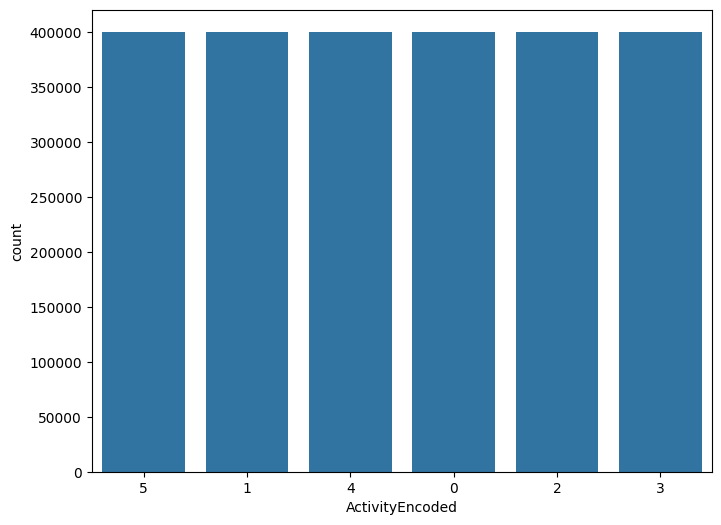

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(x = "ActivityEncoded", data = df_train_balanced, order = df_train_balanced.ActivityEncoded.value_counts().index)
     

In [21]:
#############################################
# 2. 시계열 데이터 세그먼테이션 함수 정의
#############################################
def create_dataset(X, y, time_steps=1, step=1):
    """
    X: 센서 데이터가 담긴 DataFrame (예: ["x_axis", "y_axis", "z_axis"])
    y: 라벨(인코딩된 값)이 담긴 Series (예: df["ActivityEncoded"])
    time_steps: 각 시퀀스(윈도우)의 길이 (예: 200)
    step: 윈도우 생성 시 이동 간격 (예: 40)
    """
    Xs, ys = [], []
    for i in range(0, len(X) - time_steps, step):
        # i부터 i+time_steps까지의 센서 데이터를 numpy 배열로 변환
        v = X.iloc[i:(i + time_steps)].values
        # 해당 구간의 라벨들을 선택하고, 다수결(mode)로 대표 라벨 결정
        window_labels = y.iloc[i:(i + time_steps)]
        mode_result = stats.mode(window_labels)
        mode_label = mode_result.mode
        # 만약 mode_label이 배열이면 첫 번째 원소 선택
        if isinstance(mode_label, np.ndarray):
            mode_label = mode_label[0]
        Xs.append(v)
        ys.append(mode_label)
    return np.array(Xs), np.array(ys).reshape(-1, 1)

In [22]:
#최반값으로. 라벨
TIME_STEPS = 200  # 각 윈도우(시퀀스)의 길이
STEP = 40
X_train, y_train = create_dataset(
    df_train_balanced[["x_axis", "y_axis", "z_axis"]],
    df_train_balanced["ActivityEncoded"],
    time_steps=TIME_STEPS,
    step=STEP
)

X_test, y_test = create_dataset(
    test_df[["x_axis", "y_axis", "z_axis"]],
    test_df["ActivityEncoded"],
    time_steps=TIME_STEPS,
    step=STEP
)

# 3. train셋에서 validation셋 분리 (train 데이터의 일부를 validation으로 사용)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (48044, 200, 3) (48044, 1)
Validation shape: (12011, 200, 3) (12011, 1)
Test shape: (3595, 200, 3) (3595, 1)


In [23]:
#############################################
# 4. PyTorch DataLoader 준비
#############################################
import torch
from torch.utils.data import DataLoader, TensorDataset

def prepare_loader(X, y, batch_size=64):
    # CNN 모델 입력은 (batch, channels, length) → 변환: (N, window_size, 3) → (N, 3, window_size)
    X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
    # y는 정수형 라벨, shape (N,1) -> squeeze하여 (N,)
    y_tensor = torch.tensor(y, dtype=torch.long).squeeze()
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader

train_loader = prepare_loader(X_train, y_train, batch_size=64)
val_loader = prepare_loader(X_val, y_val, batch_size=64)
test_loader = prepare_loader(X_test, y_test, batch_size=64)


In [26]:

#############################################
# 5. 간단한 1D CNN 분류기 정의
#############################################
import torch.nn as nn
import torch.optim as optim

# Device 설정 (MPS, CUDA 또는 CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple GPU)")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, window_size=200):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * (window_size // 4), 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Using device: MPS (Apple GPU)


In [35]:
#############################################
# 6. 모델 학습 및 평가
#############################################
num_epochs = 50  # 학습 에폭 수
window_size=200
model = SimpleCNN(num_classes=num_classes, window_size=window_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("\n=== 모델 학습 시작 ===")
# 에폭별 손실과 정확도를 저장할 리스트
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == y_batch)
        total_train += y_batch.size(0)
    
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc.item())
    
    # Validation Phase
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    total_val = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_running_loss += loss.item() * X_val.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == y_val)
            total_val += y_val.size(0)
    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = val_running_corrects.float() / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc.item())
    
    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")



=== 모델 학습 시작 ===
Epoch 1/50, Train Loss: 0.3010, Train Acc: 0.8894, Val Loss: 0.1327, Val Acc: 0.9545
Epoch 2/50, Train Loss: 0.1068, Train Acc: 0.9614, Val Loss: 0.0934, Val Acc: 0.9673
Epoch 3/50, Train Loss: 0.0664, Train Acc: 0.9755, Val Loss: 0.0711, Val Acc: 0.9765
Epoch 4/50, Train Loss: 0.0390, Train Acc: 0.9863, Val Loss: 0.0746, Val Acc: 0.9737
Epoch 5/50, Train Loss: 0.0304, Train Acc: 0.9892, Val Loss: 0.0724, Val Acc: 0.9771
Epoch 6/50, Train Loss: 0.0303, Train Acc: 0.9898, Val Loss: 0.0635, Val Acc: 0.9793
Epoch 7/50, Train Loss: 0.0143, Train Acc: 0.9951, Val Loss: 0.0743, Val Acc: 0.9770
Epoch 8/50, Train Loss: 0.0141, Train Acc: 0.9955, Val Loss: 0.0701, Val Acc: 0.9799
Epoch 9/50, Train Loss: 0.0162, Train Acc: 0.9946, Val Loss: 0.0730, Val Acc: 0.9810
Epoch 10/50, Train Loss: 0.0137, Train Acc: 0.9957, Val Loss: 0.0640, Val Acc: 0.9803
Epoch 11/50, Train Loss: 0.0160, Train Acc: 0.9948, Val Loss: 0.1182, Val Acc: 0.9699
Epoch 12/50, Train Loss: 0.0043, Train Acc: 0

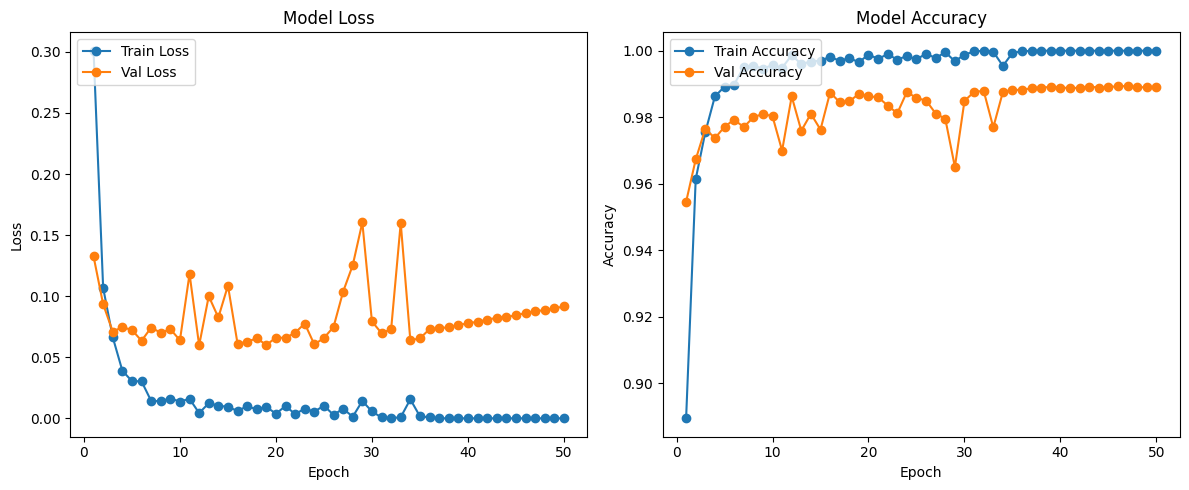

In [36]:
# 학습 및 검증 결과 플롯팅
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 손실 플롯
plt.subplot(1, 2, 1)


plt.plot(range(1, num_epochs+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

# 정확도 플롯
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, marker='o', label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [37]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).squeeze()  # 만약 y_batch가 (batch_size, 1)이라면
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"테스트 정확도: {accuracy:.2f}%")

테스트 정확도: 82.78%


F1 Score (weighted): 0.826922983279896
Accuracy: 0.8278164116828929
Classification Report:
              precision    recall  f1-score   support

     Walking       0.78      0.74      0.76       598
     Jogging       0.86      0.86      0.86       600
    Upstairs       1.00      1.00      1.00       600
  Downstairs       1.00      0.83      0.91       600
     Sitting       0.67      0.59      0.62       600
    Standing       0.71      0.95      0.81       597

    accuracy                           0.83      3595
   macro avg       0.83      0.83      0.83      3595
weighted avg       0.84      0.83      0.83      3595



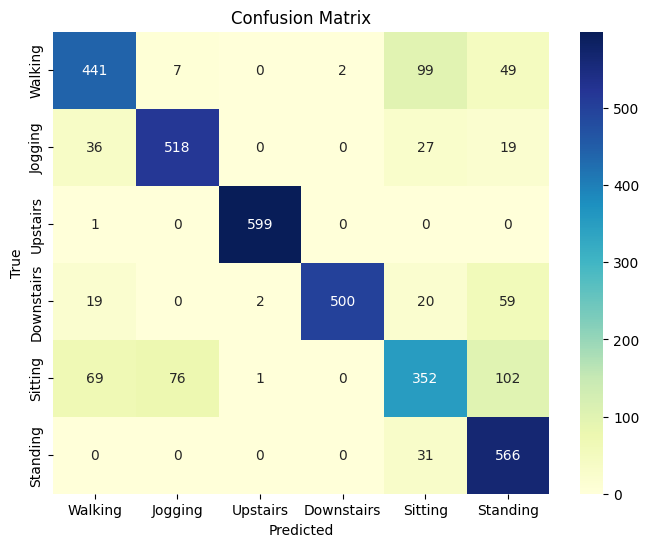

In [38]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# LABELS는 클래스 이름을 지정합니다.
LABELS = ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']

# 모델을 평가 모드로 전환
model.eval()

# 전체 test 데이터에 대해 예측값과 정답을 모읍니다.
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(X_batch)
        # 각 샘플에 대해 가장 높은 확률을 가진 클래스 인덱스 선택
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

# 혼동 행렬 계산
cm = confusion_matrix(all_true, all_preds)

# 평가 지표 출력
print("F1 Score (weighted):", f1_score(all_true, all_preds, average='weighted'))
print("Accuracy:", accuracy_score(all_true, all_preds))
print("Classification Report:")
print(classification_report(all_true, all_preds, target_names=LABELS))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="YlGnBu", xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()